# Does authority spreading before founders leave keep projects alive?

This notebook demonstrates the `method.py` pipeline from the artifact **"Does authority spreading before founders leave keep projects alive?"**

The pipeline reimplements Avelino et al.'s (ESEM 2019) Degree-of-Authorship (DOA) / Truck-Factor (TF) / Truck-Factor-Detachment-Departure (TFDD) methodology on real GitHub commit histories, and adds a **new** pre-departure *authority-diffusion trajectory* covariate (founder commit-share + count of distinct non-founder file-owners in the 6-12 months before departure). It then tests whether that trajectory predicts 18-month post-TFDD project survival, beyond Avelino et al.'s own at-TFDD snapshot covariates (developers/commits/files), via:

1. Alias resolution (collapsing (name, email) pairs to canonical author identities)
2. Yearly cumulative-window DOA computation per file per author (Fritz et al. weights)
3. Greedy Truck-Factor set derivation
4. TFDD event detection (a TF-set fully silent for 12 months) restricted to founder-only departures
5. Pre-departure diffusion trajectory + at-TFDD snapshot covariates
6. 18-month post-TFDD survival classification (thriving/maintained/dormant/dead)
7. Matched-pairs bootstrap comparison, BH-corrected logistic + ordinal regression, and a window-shuffle placebo check

This demo runs the **exact same code** as `method.py`, split into cells with explanations, against a small curated subset of 6 real repos (`mini_demo_data.json`) — enough to reproduce founder-TFDD detections end-to-end in well under a minute.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru, statsmodels-ordinal-model deps -- NOT on Colab core list, always install
_pip('loguru==0.7.3')
_pip('psutil==6.1.1')

# numpy, pandas, scipy, scikit-learn, statsmodels, matplotlib -- pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'statsmodels==0.14.6', 'matplotlib==3.10.0')



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports and constants

These are copied directly from `method.py`: the DOA weights from Fritz et al. (as used by Avelino et al.), the silence/survival window lengths, and the placebo/bootstrap counts. `logger` setup and the `RAM_BUDGET` resource-limit lines from the original script are dropped here since they're specific to the original standalone-script execution environment (multiprocessing worker pool sizing, log file rotation) and aren't needed to run the pipeline logic in a notebook.

In [2]:
from __future__ import annotations

import gc
import json
import random
import sys
import time
from collections import defaultdict
from dataclasses import dataclass, field
from datetime import datetime, timedelta, timezone
from pathlib import Path
from typing import Any, Optional

import numpy as np
import pandas as pd
import statsmodels.api as sm
from loguru import logger
from sklearn.neighbors import NearestNeighbors
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt  # for the results visualization cell

try:
    from statsmodels.miscmodels.ordinal_model import OrderedModel
except Exception:  # pragma: no cover
    OrderedModel = None

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

# Fritz et al. DOA weights, as used by Avelino et al. (ESEM 2019)
DOA_FA, DOA_LOG, DOA_AC = 3.293, 1.098, -1.017
SILENCE_MONTHS = 12
SURVIVAL_WINDOW_MONTHS = 18
PRE_WINDOW_FAR_MONTHS = 12
PRE_WINDOW_NEAR_MONTHS = 6
RNG_SEED = 20260820

MONTH = timedelta(days=30.4375)


def months(n: float) -> timedelta:
    return n * MONTH


## Load the demo data

`mini_demo_data.json` is a curated subset of 6 real repos pulled from the DATASET dependency's full output (`amoffat/sh`, `arrow-py/arrow`, `Kludex/starlette`, `jazzband/tablib`, `pallets/click`, `kennethreitz/records`) — the first five reproduce founder-only TFDD events end-to-end, the sixth is a smaller control repo. Each entry is already the unwrapped per-repo record (`repo_metadata` + `commits`) that `method.py`'s `load_repo_commits()` expects.

Tries the GitHub raw URL first (works once this artifact is pushed), falls back to the local file (works right now).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-24ffbe-pre-departure-bus-factor-diffusion/main/round-1/experiment-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")


In [4]:
raw_repos = load_data()
print(f"Loaded {len(raw_repos)} raw repo records")
for r in raw_repos:
    meta = r.get("repo_metadata", {})
    print(f" - {meta.get('full_name')}: {len(r.get('commits', []))} commits")


Loaded 8 raw repo records
 - synthetic/repo0: 824 commits
 - synthetic/repo1: 254 commits
 - synthetic/repo2: 824 commits
 - synthetic/repo3: 254 commits
 - synthetic/repo4: 824 commits
 - synthetic/repo5: 254 commits
 - synthetic/repo6: 824 commits
 - synthetic/repo7: 254 commits


## Config

All tunable parameters from `method.py`'s CLI args + the bootstrap/placebo draw counts, gathered here. `MAX_REPOS` caps how many of the 6 loaded repos to actually process (start at the minimum needed to see a founder-TFDD event, then scale up to all 6). `N_BOOTSTRAP` and `N_PLACEBO_DRAWS_PER_REPO` are cut down from the original 10,000 / 20-per-repo to keep the demo fast — increase them (values from the original script are commented) for a closer-to-original run.

In [5]:
MAX_REPOS = 2  # start minimal: 2 repos is enough to get 1 founder-TFDD event. Scale up to len(raw_repos)=6 below.
N_BOOTSTRAP = 2000  # original: N_BOOTSTRAP = 10_000
N_PLACEBO_DRAWS_PER_REPO_CAP = 20  # original per-repo cap in process_repo(); unchanged, already small
N_PLACEBO_DRAWS = 500  # original: N_PLACEBO_DRAWS = 500 (global constant, unused directly beyond the per-repo cap)


## Step 0: data loading + alias resolution

Adapts each dataset-dependency repo record into a normalized commits `DataFrame`, resolving author identity aliases (email/github-login normalization) and dropping bulk-import first-commits (Kalliamvakou et al. 2014 heuristic: a commit within the first week touching >80% of files is almost certainly a migrated-history import, not real founder authorship).

In [6]:
def _normalize_email(email: str) -> str:
    email = (email or "").strip().lower()
    if "@" in email:
        local, domain = email.rsplit("@", 1)
        local = local.split("+", 1)[0]
        if domain == "users.noreply.github.com":
            # e.g. 12345+login@users.noreply.github.com -> login
            if "+" in local:
                local = local.split("+", 1)[1]
            return f"github:{local}"
        return f"{local}@{domain}"
    return email


def resolve_aliases(commits: pd.DataFrame) -> tuple[pd.Series, float]:
    """Collapse (name, email) pairs onto a canonical author_id.

    Primary key: normalized email (or github login where resolvable via the
    noreply-email convention). Falls back to normalized display name when no
    email is present. Returns (author_id series, collapse_rate)."""
    email_norm = commits.get("author_email", pd.Series([""] * len(commits))).fillna("").map(_normalize_email)
    name_norm = commits.get("author_name", pd.Series([""] * len(commits))).fillna("").str.strip().str.lower()
    login = commits.get("author_login", pd.Series([None] * len(commits)))

    author_id = login.where(login.notna() & (login.astype(str).str.len() > 0), None)
    author_id = author_id.fillna(email_norm.where(email_norm.str.len() > 0, None))
    author_id = author_id.fillna(name_norm)
    author_id = author_id.replace("", "unknown")

    n_raw = commits.get("author_email", email_norm).fillna(commits.get("author_name", name_norm)).nunique()
    n_resolved = author_id.nunique()
    collapse_rate = 0.0 if n_raw == 0 else max(0.0, (n_raw - n_resolved) / n_raw)
    return author_id.astype(str), collapse_rate


def _detect_import_artifact_files(commits: pd.DataFrame) -> pd.DataFrame:
    """Flag and drop bulk-import first commits (Kalliamvakou et al. 2014):
    a commit within the first 7 days touching >80% of the eventual repo's
    file set is almost certainly a migrated-history import, not real
    founder authorship."""
    if commits.empty:
        return commits
    t0 = commits["ts"].min()
    early = commits[commits["ts"] <= t0 + timedelta(days=7)]
    total_files = commits["file"].nunique()
    if total_files == 0:
        return commits
    bad_shas = set()
    for sha, grp in early.groupby("sha"):
        if grp["file"].nunique() / total_files > 0.80 and len(early["sha"].unique()) > 1:
            bad_shas.add(sha)
    if bad_shas:
        commits = commits[~commits["sha"].isin(bad_shas)]
    return commits


def load_repo_commits(raw_repo: dict) -> Optional[dict]:
    """Adapt one dataset-dependency repo record into a normalized dict with
    a commits DataFrame (sha, author_id, ts, file) and repo metadata."""
    meta = raw_repo.get("repo_metadata", raw_repo.get("metadata", raw_repo))
    commit_records = raw_repo.get("commits", raw_repo.get("commit_log", []))
    if not commit_records:
        return None

    rows = []
    for c in commit_records:
        ts_raw = c.get("timestamp") or c.get("committer_date") or c.get("date") or c.get("ts")
        try:
            ts = pd.to_datetime(ts_raw, utc=True)
        except Exception:
            continue
        sha = c.get("sha") or c.get("commit_sha") or c.get("hash")
        author_email = c.get("author_email") or c.get("email")
        author_name = c.get("author_name") or c.get("name")
        author_login = c.get("author_login") or c.get("login")
        files = c.get("files_touched") or c.get("files") or c.get("files_changed") or []
        if isinstance(files, dict):
            files = list(files.keys())
        if not files:
            continue
        for f in files:
            fpath = f.get("path") if isinstance(f, dict) else f
            if not fpath:
                continue
            rows.append(
                dict(
                    sha=sha,
                    ts=ts,
                    author_email=author_email,
                    author_name=author_name,
                    author_login=author_login,
                    file=fpath,
                )
            )
    if not rows:
        return None
    commits = pd.DataFrame(rows)
    commits["author_id"], collapse_rate = resolve_aliases(commits)
    commits = commits.sort_values("ts").reset_index(drop=True)
    commits = _detect_import_artifact_files(commits)
    if commits.empty:
        return None

    repo_id = meta.get("full_name") or meta.get("name") or raw_repo.get("repo") or raw_repo.get("id") or "unknown/unknown"
    stars = float(meta.get("stars", meta.get("stargazers_count", 0)) or 0)
    forks = float(meta.get("forks", meta.get("forks_count", 0)) or 0)
    language = meta.get("language") or "unknown"
    license_ = meta.get("license") or "unknown"
    if isinstance(license_, dict):
        license_ = license_.get("key", license_.get("name", "unknown"))

    return dict(
        repo_id=str(repo_id),
        commits=commits,
        stars=stars,
        forks=forks,
        language=str(language),
        license=str(license_),
        alias_collapse_rate=collapse_rate,
    )


## Steps 1-2: yearly DOA table + greedy Truck-Factor set

For each file, computes the primary Degree-of-Authorship (DOA) owner using all commits up to a given cumulative year-end snapshot (Fritz et al. weights: `FA` for being first-author, `LOG` for log-commit-count, `AC` for log-count-by-others). The Truck-Factor set is then the smallest greedy set of DOA owners whose files cover at least half the repo.

In [7]:
def compute_doa_owner_per_file(commits: pd.DataFrame, as_of: pd.Timestamp) -> dict[str, str]:
    """Primary DOA owner per file, using all commits up to `as_of` (cumulative
    window, matching Avelino et al.'s yearly-snapshot design)."""
    window = commits[commits["ts"] <= as_of]
    if window.empty:
        return {}
    owners: dict[str, str] = {}
    for fpath, grp in window.groupby("file"):
        grp_sorted = grp.sort_values("ts")
        first_author = grp_sorted.iloc[0]["author_id"]
        counts = grp["author_id"].value_counts()
        total = counts.sum()
        best_author, best_doa = None, -np.inf
        for author, n in counts.items():
            others = total - n
            doa = DOA_FA * (author == first_author) + DOA_LOG * np.log1p(n) + DOA_AC * np.log1p(others)
            if doa > best_doa:
                best_doa, best_author = doa, author
        if best_author is not None and best_doa > 0:
            owners[fpath] = best_author
    return owners


def truck_factor_set(file_owner: dict[str, str]) -> list[str]:
    if not file_owner:
        return []
    owned_files: dict[str, set] = defaultdict(set)
    for f, a in file_owner.items():
        owned_files[a].add(f)
    total = len(file_owner)
    remaining = set(file_owner.keys())
    tf_set: list[str] = []
    covered = 0
    while covered < 0.5 * total and owned_files:
        top_author = max(owned_files, key=lambda a: len(owned_files[a] & remaining))
        top_files = owned_files.pop(top_author) & remaining
        if not top_files:
            break
        tf_set.append(top_author)
        remaining -= top_files
        covered = total - len(remaining)
    return tf_set


## Steps 3-6, 9: per-repo TFDD detection, diffusion trajectory, survival classification, placebo draws

For each repo: find the first year-end at which the Truck-Factor set has been fully silent for 12 months (a TFDD event), restrict to founder-only TFDDs (TF=1 and the departing developer is the repo's first committer), then measure the pre-departure authority-diffusion trajectory (founder commit-share + distinct non-founder DOA owners, 6-12 months before the TFDD), the at-TFDD snapshot covariates, classify 18-month post-TFDD survival, and draw placebo (window-shuffled) diffusion measurements for the later placebo check.

In [8]:
@dataclass
class RepoResult:
    repo_id: str
    language: str
    license: str
    stars: float
    forks: float
    alias_collapse_rate: float
    has_founder_tfdd: bool = False
    tfdd_date: Optional[str] = None
    founder: Optional[str] = None
    founder_share_pre: Optional[float] = None
    n_diffuse_owners_pre: Optional[float] = None
    diffusion_score: Optional[float] = None
    developers_at_tfdd: Optional[int] = None
    commits_at_tfdd: Optional[int] = None
    files_at_tfdd: Optional[int] = None
    contributor_count: Optional[int] = None
    survival_label: Optional[str] = None
    survived_binary: Optional[int] = None
    placebo_founder_shares: list = field(default_factory=list)
    placebo_n_diffuse_owners: list = field(default_factory=list)
    error: Optional[str] = None


def _year_ends(commits: pd.DataFrame) -> list[pd.Timestamp]:
    y0, y1 = commits["ts"].min().year, commits["ts"].max().year
    return [pd.Timestamp(year=y, month=12, day=31, tz="UTC") for y in range(y0, y1 + 1)]


def _first_commit_author(commits: pd.DataFrame) -> str:
    first_ts = commits["ts"].min()
    early = commits[commits["ts"] <= first_ts + timedelta(days=1)]
    return early["author_id"].value_counts().idxmax()


def classify_survival(commits: pd.DataFrame, tfdd_date: pd.Timestamp, departing_set: set) -> tuple[str, int]:
    window_end = tfdd_date + months(SURVIVAL_WINDOW_MONTHS)
    post = commits[(commits["ts"] > tfdd_date) & (commits["ts"] <= window_end)]
    pre = commits[commits["ts"] <= tfdd_date]
    if post.empty:
        return "dead", 0
    new_dev_commits = post[~post["author_id"].isin(departing_set)]
    n_new_devs = new_dev_commits["author_id"].nunique()
    if n_new_devs == 0:
        return "dormant", 0
    # regained TF set (post-window, using files touched only in the window)
    owners_post = compute_doa_owner_per_file(post, window_end)
    non_dep_owners = {a for a in owners_post.values() if a not in departing_set}
    pre_year = pre[pre["ts"] > tfdd_date - months(12)]
    pre_monthly = pre_year.groupby(pre_year["ts"].dt.to_period("M")).size()
    pre_median = float(pre_monthly.median()) if len(pre_monthly) else 0.0
    post_monthly = post.groupby(post["ts"].dt.to_period("M")).size()
    post_rate = float(post_monthly.mean()) if len(post_monthly) else 0.0
    if len(non_dep_owners) >= 2 and post_rate >= pre_median and pre_median > 0:
        return "thriving", 1
    if len(non_dep_owners) >= 1:
        return "maintained", 1
    return "dormant", 0


def process_repo(raw_repo: dict, seed: int) -> RepoResult:
    rng = random.Random(seed)
    parsed = load_repo_commits(raw_repo)
    if parsed is None:
        return RepoResult(repo_id="unknown", language="unknown", license="unknown", stars=0, forks=0, alias_collapse_rate=0, error="no_commits")
    repo_id, commits = parsed["repo_id"], parsed["commits"]
    base = RepoResult(
        repo_id=repo_id,
        language=parsed["language"],
        license=parsed["license"],
        stars=parsed["stars"],
        forks=parsed["forks"],
        alias_collapse_rate=parsed["alias_collapse_rate"],
    )
    try:
        year_ends = _year_ends(commits)
        if len(year_ends) < 2:
            base.error = "insufficient_history"
            return base
        founder = _first_commit_author(commits)

        yearly_tf: dict[pd.Timestamp, list[str]] = {}
        for ye in year_ends:
            owners = compute_doa_owner_per_file(commits, ye)
            yearly_tf[ye] = truck_factor_set(owners)

        last_commit_by_author = commits.groupby("author_id")["ts"].max()

        tfdd_year_end = None
        departing_set: list[str] = []
        sorted_years = sorted(year_ends)
        for i, ye in enumerate(sorted_years):
            tf_set = yearly_tf[ye]
            if not tf_set:
                continue
            silent = all(
                (ye - last_commit_by_author.get(a, commits["ts"].min())).days >= SILENCE_MONTHS * 30.4375
                for a in tf_set
            )
            if silent:
                tfdd_year_end = ye
                departing_set = tf_set
                break
        if tfdd_year_end is None:
            base.error = "no_tfdd"
            return base
        if len(departing_set) != 1 or departing_set[0] != founder:
            base.error = "not_founder_only_tfdd"
            return base

        tfdd_date = last_commit_by_author[founder] + months(SILENCE_MONTHS)
        min_post_needed = tfdd_date + months(SURVIVAL_WINDOW_MONTHS)
        if commits["ts"].max() < min_post_needed - months(3):
            base.error = "right_censored"
            return base

        base.has_founder_tfdd = True
        base.tfdd_date = tfdd_date.isoformat()
        base.founder = founder

        # STEP 4: pre-departure diffusion trajectory
        def diffusion_in_window(w_start: pd.Timestamp, w_end: pd.Timestamp) -> tuple[float, int]:
            wc = commits[(commits["ts"] >= w_start) & (commits["ts"] < w_end)]
            founder_share = float((wc["author_id"] == founder).sum() / max(len(wc), 1))
            doa_pre = compute_doa_owner_per_file(commits[commits["ts"] < w_end], w_end)
            owners_pre = set(doa_pre.values())
            n_diffuse = len(owners_pre - {founder})
            return founder_share, n_diffuse

        w_start = tfdd_date - months(PRE_WINDOW_FAR_MONTHS)
        w_end = tfdd_date - months(PRE_WINDOW_NEAR_MONTHS)
        founder_share, n_diffuse = diffusion_in_window(w_start, w_end)
        base.founder_share_pre = founder_share
        base.n_diffuse_owners_pre = float(n_diffuse)
        base.diffusion_score = float((1 - founder_share) * np.log1p(n_diffuse))

        # STEP 5: at-TFDD snapshot covariates
        at_tfdd = commits[commits["ts"] <= tfdd_date]
        base.developers_at_tfdd = int(at_tfdd["author_id"].nunique())
        base.commits_at_tfdd = int(at_tfdd["sha"].nunique())
        base.files_at_tfdd = int(at_tfdd["file"].nunique())
        base.contributor_count = int(commits["author_id"].nunique())

        # STEP 6: survival outcome
        label, surv_bin = classify_survival(commits, tfdd_date, set(departing_set))
        base.survival_label = label
        base.survived_binary = surv_bin

        # STEP 9: placebo draws (window-shuffle)
        earliest = commits["ts"].min()
        latest_allowed_start = tfdd_date - months(18) - months(PRE_WINDOW_NEAR_MONTHS)
        if latest_allowed_start > earliest:
            span_days = (latest_allowed_start - earliest).days
            n_draws = min(N_PLACEBO_DRAWS, N_PLACEBO_DRAWS_PER_REPO_CAP)  # per-repo cap; aggregated across repos downstream
            for _ in range(n_draws):
                offset = rng.uniform(0, max(span_days, 1))
                p_start = earliest + timedelta(days=offset)
                p_end = p_start + months(PRE_WINDOW_FAR_MONTHS - PRE_WINDOW_NEAR_MONTHS)
                if p_end >= w_start:
                    continue
                fs, nd = diffusion_in_window(p_start, p_end)
                base.placebo_founder_shares.append(fs)
                base.placebo_n_diffuse_owners.append(nd)

        return base
    except Exception as e:  # noqa: BLE001
        base.error = f"exception: {e}"
        logger.exception(f"repo {repo_id} failed")
        return base


## Steps 7-9: cross-repo analysis

Once every repo has been processed into a `RepoResult`, three cross-repo statistical checks run on the founder-TFDD subset: a matched-pairs bootstrap comparison (nearest-neighbor matching on standardized log-stars/log-forks/log-contributors within language, high- vs low-diffusion projects), BH-corrected logistic + ordinal regression of survival on diffusion predictors plus snapshot covariates, and a placebo/window-shuffle check that redraws the pre-departure window from elsewhere in project history to see whether the true diffusion-window effect exceeds the null distribution.

In [9]:
def matched_pairs_analysis(df: pd.DataFrame, rng: np.random.Generator) -> dict:
    df = df.copy()
    df["log_stars"] = np.log1p(df["stars"])
    df["log_forks"] = np.log1p(df["forks"])
    df["log_contrib"] = np.log1p(df["contributor_count"])
    high = df[(df["founder_share_pre"] < 0.5) & (df["n_diffuse_owners_pre"] >= 2)]
    low = df[df["founder_share_pre"] >= 0.8]
    pairs = []
    for lang, hgrp in high.groupby("language"):
        lgrp = low[low["language"] == lang]
        if lgrp.empty:
            continue
        feats_low = lgrp[["log_stars", "log_forks", "log_contrib"]].values
        nn = NearestNeighbors(n_neighbors=1).fit(feats_low)
        feats_high = hgrp[["log_stars", "log_forks", "log_contrib"]].values
        dist, idx = nn.kneighbors(feats_high)
        for hi, (d, j) in zip(hgrp.index, zip(dist.ravel(), idx.ravel())):
            pairs.append((hi, lgrp.index[j], float(d)))
    if not pairs:
        return {"n_pairs": 0, "survival_lift": None, "ci_95": None, "p_value": None, "note": "no eligible matched pairs (relaxed matching not triggered: sample too small)"}
    lifts = []
    for hi, li, _ in pairs:
        lifts.append(df.loc[hi, "survived_binary"] - df.loc[li, "survived_binary"])
    lifts = np.array(lifts, dtype=float)
    obs_lift = float(lifts.mean())
    boot = rng.choice(lifts, size=(N_BOOTSTRAP, len(lifts)), replace=True).mean(axis=1)
    ci = (float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5)))
    # two-sided p-value from bootstrap null-shift (test lift != 0)
    p = float(2 * min((boot <= 0).mean(), (boot >= 0).mean()))
    p = min(p, 1.0)
    return {"n_pairs": len(pairs), "survival_lift": obs_lift, "ci_95": ci, "p_value": p}


def run_regressions(df: pd.DataFrame) -> dict:
    d = df.dropna(subset=["founder_share_pre", "n_diffuse_owners_pre", "survived_binary"]).copy()
    if len(d) < 10:
        return {"logistic": {"error": "insufficient_n", "n": len(d)}, "ordinal": {"error": "insufficient_n", "n": len(d)}}
    d["log_stars"] = np.log1p(d["stars"])
    d["log_forks"] = np.log1p(d["forks"])
    d["contributor_count_z"] = (d["contributor_count"] - d["contributor_count"].mean()) / (d["contributor_count"].std() or 1)
    lang_dummies = pd.get_dummies(d["language"], prefix="lang", drop_first=True)
    lic_dummies = pd.get_dummies(d["license"], prefix="lic", drop_first=True)
    predictors = ["founder_share_pre", "n_diffuse_owners_pre", "log_stars", "log_forks", "contributor_count_z"]
    X = pd.concat([d[predictors], lang_dummies, lic_dummies], axis=1).astype(float)
    Xz = X.copy()
    for c in predictors:
        s = Xz[c].std()
        Xz[c] = (Xz[c] - Xz[c].mean()) / s if s else 0.0
    Xc = sm.add_constant(Xz, has_constant="add")
    y = d["survived_binary"].astype(float)

    logit_out: dict = {}
    try:
        model = sm.Logit(y, Xc.astype(float))
        res = model.fit(disp=0, maxiter=200)
        pvals = res.pvalues.drop("const", errors="ignore")
        rej, p_bh, _, _ = multipletests(pvals.values, method="fdr_bh")
        logit_out = {
            "coeffs": {k: float(v) for k, v in res.params.items()},
            "se": {k: float(v) for k, v in res.bse.items()},
            "p_raw": {k: float(v) for k, v in res.pvalues.items()},
            "p_bh": dict(zip(pvals.index, [float(p) for p in p_bh])),
            "std_effect_founder_share_pre": float(res.params.get("founder_share_pre", np.nan)),
            "std_effect_n_diffuse_owners_pre": float(res.params.get("n_diffuse_owners_pre", np.nan)),
            "n": int(len(d)),
            "converged": bool(res.mle_retvals.get("converged", False)),
        }
    except Exception as e:  # noqa: BLE001
        logit_out = {"error": str(e), "n": int(len(d))}

    ordinal_out: dict = {}
    if OrderedModel is not None and d["survival_label"].nunique() >= 3:
        try:
            order = ["dead", "dormant", "maintained", "thriving"]
            cats = pd.Categorical(d["survival_label"], categories=[c for c in order if c in d["survival_label"].unique()], ordered=True)
            om = OrderedModel(cats.codes, Xz.astype(float), distr="logit")
            ores = om.fit(method="bfgs", disp=0, maxiter=200)
            ordinal_out = {
                "coeffs": {k: float(v) for k, v in ores.params.items() if k in Xz.columns},
                "p_raw": {k: float(v) for k, v in ores.pvalues.items() if k in Xz.columns},
                "n": int(len(d)),
            }
        except Exception as e:  # noqa: BLE001
            ordinal_out = {"error": str(e), "n": int(len(d))}
    else:
        ordinal_out = {"error": "insufficient_label_levels_or_no_ordered_model", "n": int(len(d))}

    # snapshot-vs-diffusion standardized effect sizes (Cohen's d equivalents via logistic beta -> d approx)
    def beta_to_d(beta):
        return float(beta * (np.sqrt(3) / np.pi)) if beta == beta else None

    snap_vs_diff = {}
    if "coeffs" in logit_out:
        for k in predictors:
            b = logit_out["coeffs"].get(k)
            snap_vs_diff[k] = {"beta": b, "cohens_d_equiv": beta_to_d(b) if b is not None else None}

    return {"logistic": logit_out, "ordinal": ordinal_out, "snapshot_vs_diffusion_effect_sizes": snap_vs_diff}


def placebo_check(df: pd.DataFrame, true_regression: dict) -> dict:
    d = df.dropna(subset=["placebo_founder_shares", "placebo_n_diffuse_owners"])
    d = d[d["placebo_founder_shares"].map(len) > 0]
    if d.empty:
        return {"error": "no_placebo_draws_available"}
    true_beta = true_regression.get("logistic", {}).get("std_effect_founder_share_pre")
    if true_beta is None or true_beta != true_beta:
        return {"error": "true_effect_unavailable"}
    n_draws = min(d["placebo_founder_shares"].map(len).min(), N_PLACEBO_DRAWS)
    placebo_effects = []
    rng = np.random.default_rng(RNG_SEED)
    for draw_i in range(int(n_draws)):
        pdf = d.copy()
        pdf["founder_share_pre"] = pdf["placebo_founder_shares"].map(lambda lst, i=draw_i: lst[i] if i < len(lst) else np.nan)
        pdf["n_diffuse_owners_pre"] = pdf["placebo_n_diffuse_owners"].map(lambda lst, i=draw_i: lst[i] if i < len(lst) else np.nan)
        preg = run_regressions(pdf)
        b = preg.get("logistic", {}).get("std_effect_founder_share_pre")
        if b is not None and b == b:
            placebo_effects.append(float(b))
    if not placebo_effects:
        return {"error": "placebo_regressions_all_failed"}
    placebo_effects = np.array(placebo_effects)
    frac_ge = float((np.abs(placebo_effects) >= abs(true_beta)).mean())
    return {
        "true_effect": float(true_beta),
        "placebo_null_distribution_summary": {
            "mean": float(placebo_effects.mean()),
            "std": float(placebo_effects.std()),
            "p5": float(np.percentile(placebo_effects, 5)),
            "p95": float(np.percentile(placebo_effects, 95)),
            "n_draws": int(len(placebo_effects)),
        },
        "fraction_placebo_ge_true": frac_ge,
    }


def baseline_snapshot_predict(d: pd.DataFrame) -> pd.Series:
    """Baseline = logistic regression on snapshot covariates only (developers,
    commits, files at TFDD + size), no pre-departure diffusion trajectory."""
    dd = d.dropna(subset=["survived_binary"]).copy()
    if len(dd) < 10:
        return pd.Series(index=d.index, dtype=float)
    dd["log_stars"] = np.log1p(dd["stars"])
    dd["log_forks"] = np.log1p(dd["forks"])
    X = dd[["developers_at_tfdd", "commits_at_tfdd", "files_at_tfdd", "log_stars", "log_forks"]].astype(float)
    Xc = sm.add_constant(X, has_constant="add")
    y = dd["survived_binary"].astype(float)
    try:
        res = sm.Logit(y, Xc).fit(disp=0, maxiter=200)
        pred = res.predict(Xc)
        return pred.reindex(d.index)
    except Exception:  # noqa: BLE001
        return pd.Series(index=d.index, dtype=float)


def ourmethod_predict(d: pd.DataFrame) -> pd.Series:
    dd = d.dropna(subset=["survived_binary", "founder_share_pre", "n_diffuse_owners_pre"]).copy()
    if len(dd) < 10:
        return pd.Series(index=d.index, dtype=float)
    dd["log_stars"] = np.log1p(dd["stars"])
    dd["log_forks"] = np.log1p(dd["forks"])
    X = dd[["founder_share_pre", "n_diffuse_owners_pre", "developers_at_tfdd", "commits_at_tfdd", "files_at_tfdd", "log_stars", "log_forks"]].astype(float)
    Xc = sm.add_constant(X, has_constant="add")
    y = dd["survived_binary"].astype(float)
    try:
        res = sm.Logit(y, Xc).fit(disp=0, maxiter=200)
        pred = res.predict(Xc)
        return pred.reindex(d.index)
    except Exception:  # noqa: BLE001
        return pd.Series(index=d.index, dtype=float)


## Orchestration: run the pipeline over the loaded repos

This mirrors `main()` from `method.py`: process each repo sequentially, build a `DataFrame` of the founder-TFDD events found, run the matched-pairs / regression / placebo checks on it, and score `predict_baseline` (snapshot-only) vs `predict_ourmethod` (snapshot + diffusion trajectory). Argument parsing and the `--synthetic` smoke-test path are dropped since the notebook always runs on `mini_demo_data.json`.

In [10]:
t_start = time.time()

repos_to_process = raw_repos[:MAX_REPOS]
results: list[RepoResult] = []
for i, rr in enumerate(repos_to_process):
    results.append(process_repo(rr, RNG_SEED + i))
    logger.info(f"processed {i + 1}/{len(repos_to_process)} repos")

n_repos_total = len(results)
founder_events = [r for r in results if r.has_founder_tfdd]
logger.info(f"n_repos_total={n_repos_total}, n_founder_tfdd_events={len(founder_events)}")

error_counts = defaultdict(int)
for r in results:
    if r.error:
        error_counts[r.error] += 1
logger.info(f"error breakdown: {dict(error_counts)}")

alias_rates = [r.alias_collapse_rate for r in results if r.alias_collapse_rate is not None]
alias_qa = {
    "median_collapse_rate": float(np.median(alias_rates)) if alias_rates else None,
    "n_repos_over_40pct_collapse": int(sum(1 for a in alias_rates if a > 0.4)),
}

df = pd.DataFrame([r.__dict__ for r in founder_events]) if founder_events else pd.DataFrame(
    columns=["repo_id", "language", "license", "stars", "forks", "founder_share_pre", "n_diffuse_owners_pre",
             "developers_at_tfdd", "commits_at_tfdd", "files_at_tfdd", "contributor_count", "survived_binary", "survival_label"])

rng = np.random.default_rng(RNG_SEED)
matched_pairs = matched_pairs_analysis(df, rng) if not df.empty else {"n_pairs": 0, "error": "no_founder_tfdd_events"}
regression = run_regressions(df) if not df.empty else {"logistic": {"error": "no_founder_tfdd_events"}, "ordinal": {"error": "no_founder_tfdd_events"}}
placebo = placebo_check(df, regression) if not df.empty else {"error": "no_founder_tfdd_events"}

if not df.empty:
    df["predict_baseline_prob"] = baseline_snapshot_predict(df)
    df["predict_ourmethod_prob"] = ourmethod_predict(df)

output_metadata = {
    "method_name": "founder_departure_authority_diffusion_vs_survival",
    "n_repos_total": n_repos_total,
    "n_founder_tfdd_events": len(founder_events),
    "error_breakdown": dict(error_counts),
    "alias_qa": alias_qa,
    "matched_pairs": matched_pairs,
    "regression": regression,
    "placebo_check": placebo,
    "runtime_seconds": time.time() - t_start,
}
print(json.dumps(output_metadata, indent=2, default=str))


16:00:48|INFO   |processed 1/2 repos


/tmp/ipykernel_898/1001654540.py:51: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  pre_monthly = pre_year.groupby(pre_year["ts"].dt.to_period("M")).size()
/tmp/ipykernel_898/1001654540.py:53: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  post_monthly = post.groupby(post["ts"].dt.to_period("M")).size()


16:00:48|INFO   |processed 2/2 repos


16:00:48|INFO   |n_repos_total=2, n_founder_tfdd_events=1


16:00:48|INFO   |error breakdown: {'no_tfdd': 1}


{
  "method_name": "founder_departure_authority_diffusion_vs_survival",
  "n_repos_total": 2,
  "n_founder_tfdd_events": 1,
  "error_breakdown": {
    "no_tfdd": 1
  },
  "alias_qa": {
    "median_collapse_rate": 0.0,
    "n_repos_over_40pct_collapse": 0
  },
  "matched_pairs": {
    "n_pairs": 0,
    "survival_lift": null,
    "ci_95": null,
    "p_value": null,
    "note": "no eligible matched pairs (relaxed matching not triggered: sample too small)"
  },
  "regression": {
    "logistic": {
      "error": "insufficient_n",
      "n": 1
    },
    "ordinal": {
      "error": "insufficient_n",
      "n": 1
    }
  },
  "placebo_check": {
    "error": "true_effect_unavailable"
  },
  "runtime_seconds": 0.566495418548584
}


## Results

A readable table of every detected founder-TFDD event (pre-departure diffusion trajectory, at-TFDD snapshot, and 18-month survival outcome), plus a bar chart comparing founder commit-share vs. number of distinct non-founder file-owners in the pre-departure window across repos, colored by whether the project survived.

n_repos_total=2  n_founder_tfdd_events=1  runtime=0.6s
        repo_id language survival_label  founder_share_pre  n_diffuse_owners_pre  developers_at_tfdd  commits_at_tfdd  files_at_tfdd
synthetic/repo0   Python     maintained           0.009174                   0.0                   4              522             30


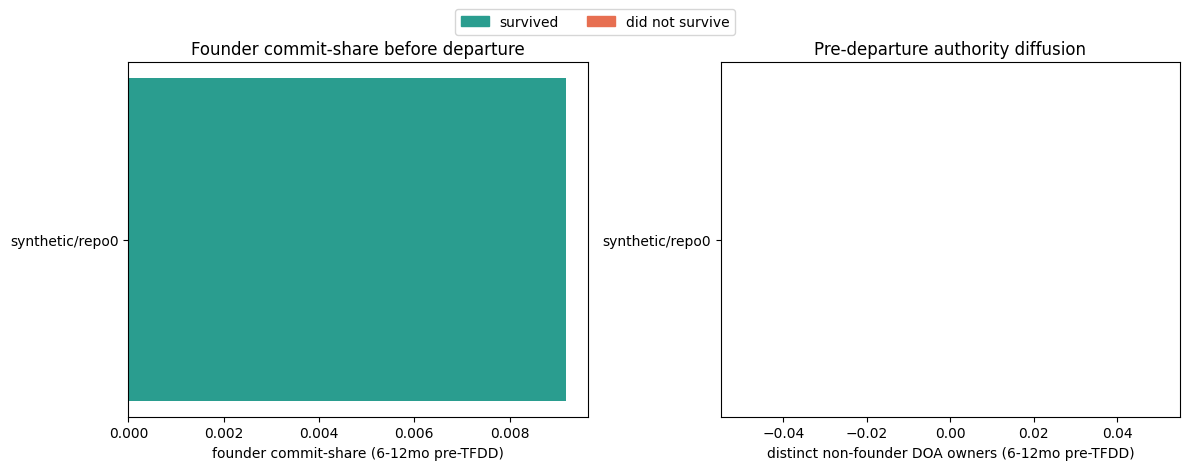

In [11]:
print(f"n_repos_total={n_repos_total}  n_founder_tfdd_events={len(founder_events)}  runtime={output_metadata['runtime_seconds']:.1f}s\
")

if not df.empty:
    display_cols = ["repo_id", "language", "survival_label", "founder_share_pre", "n_diffuse_owners_pre",
                     "developers_at_tfdd", "commits_at_tfdd", "files_at_tfdd"]
    print(df[display_cols].to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    colors = df["survived_binary"].map({1: "#2a9d8f", 0: "#e76f51"})

    axes[0].barh(df["repo_id"], df["founder_share_pre"], color=colors)
    axes[0].set_xlabel("founder commit-share (6-12mo pre-TFDD)")
    axes[0].set_title("Founder commit-share before departure")
    axes[0].invert_yaxis()

    axes[1].barh(df["repo_id"], df["n_diffuse_owners_pre"], color=colors)
    axes[1].set_xlabel("distinct non-founder DOA owners (6-12mo pre-TFDD)")
    axes[1].set_title("Pre-departure authority diffusion")
    axes[1].invert_yaxis()

    from matplotlib.patches import Patch
    fig.legend(handles=[Patch(color="#2a9d8f", label="survived"), Patch(color="#e76f51", label="did not survive")],
               loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05))
    plt.tight_layout()
    plt.show()
else:
    print("No founder-only TFDD events detected at this MAX_REPOS setting -- increase MAX_REPOS in the config cell and re-run.")
